In [1]:
from scipy.signal import correlate, correlation_lags
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import numpy as np

## Άσκηση - Εκτίμηση της θεμελιώδους συχνότητας της φωνής μας

΄Ενα πολύ σημαντικό - και ερευνητικά ενεργό - πρόβλημα στην επεξεργασία σήματος ϕωνής είναι η ακριβής εκτίμηση της θεμελιώδους συχνότητας $f_0$ της ανθρώπινης φωνής, καθώς η θεμελιώδης συχνότητα χρησιμοποιείται σε πολλές εφαρμογές, όπως για παράδειγμα στη σύνθεση ομιλίας από κείμενο (text-to-speech synthesis), σε ανίχνευση παθολογιών, στη μετατροπή ενός ομιλητή σε έναν άλλο, και σε άλλες εφαρμογές. 

Μια απλή τέτοια μέθοδος εκτίμησης είναι η **μέθοδος της αυτοσυσχέτισης**, που δίνεται ως γνωστόν ως

$$ \phi_{x}(\tau) = \int_{-\infty}^{+\infty} x(t) x(t+\tau) dt $$

Ας πούμε όμως μερικές ενδιαφέρουσες λεπτομέρειες πριν περάσουμε στην άσκηση.
Η ανθρώπινη φωνή - και συγκεκριμένα, ο έμφωνος λόγος - μπορεί να παρασταθεί ως ένα σύστημα $h(t)$, που στην είσοδό του υπάρχει ενέργεια (προερχόμενη από τους πνεύμονες) σε μορφή μιας περιοδικής σειράς από παλμούς, $x(t)$, η οποία καθορίζεται από τις φωνητικές χορδές, όπως στο παρακάτω σχήμα.

<p style="text-align: center"><img src="./files/sourcefilter.png" alt="sf" width="1200"/></p>


Πληροφοριακά και μόνο: 
- Το σήμα $x(t)$ αντιπροσωπεύει την ταχύτητα ροής του αέρα που προέρχεται από τους πνεύμονές μας, ακριβώς επάνω από τις φωνητικές μας χορδές. Το χαρακτηριστικό αυτό σχήμα που βλέπετε "σχηματίζεται" από το άνοιγμα και κλείσιμο των φωνητικών χορδών μας. Κάθε παλμός που μοιάζει με "λοφάκι" στο σχήμα αποτελεί ένα ανοιγοκλείσιμο των φωνητικών μας χορδών.
- Η είσοδος αυτή περνά σε ένα σύστημα $h(t)$, το οποίο περιγράφει τη φωνητική μας οδό, δηλ. τη θέση του στόματος, της γλώσσας, και των δοντιών, καθώς και την ανατομία του λάρυγγά μας, ανάλογα με το φώνημα που θέλουμε να εκφέρουμε. Το σύστημα $h(t)$ - που, ω, τι περίεργο, θεωρείται ως ένα ΓΧΑ σύστημα 😏 - λειτουργεί σαν φίλτρο, που ενισχύει ή καταστέλλει συγκεκριμένες συχνότητες του σήματος εισόδου $x(t)$. 
- Η έξοδος αυτού του συστήματος $y(t)$, είναι το σήμα φωνής που παράγεται, όπως φαίνεται στο σχήμα και αντιπροσωπεύει τη μεταβολή της πίεσης των μορίων του αέρα ακριβώς έξω από το στόμα μας. Ω ναι, το σήμα εισόδου είναι σήμα ταχύτητας και το σήμα εξόδου είναι σήμα μεταβολής πίεσης - οι λεπτομέρειες δεν είναι του παρόντος 😁.

Η απόσταση μεταξύ δυο διαδοχικών παλμών της εισόδου $x(t)$ ονομάζεται περίοδος $T_0$ του σήματος εισόδου. Ο λόγος $f_0 = \frac{1}{T_0}$ ονομάζεται **θεμελιώδης συχνότητα** της φωνής μας, και αντιπροσωπεύει το *ρυθμό* με τον οποίο ανοιγοκλείνουν οι φωνητικές μας χορδές. Ένα άνοιγμα και κλείσιμο των φωνητικών χορδών αντιστοιχεί σε ένα παλμό του σήματος $x(t)$, όπως το βλέπετε στο σχήμα. Βλέπετε ότι η περιοδικότητα των φωνητικών χορδών διατηρείται και στο τελικό σήμα φωνής. 

Παρ' όλο που καταλαβαίνετε ότι τα σήματα εισόδου και εξόδου δεν είναι **αυστηρώς** περιοδικά, μπορούμε να τα θεωρήσουμε ως τέτοια, θεωρώντας ότι συνεχίζονται επ' άπειρο, αλλά εμείς έχουμε "κόψει" ένα τμήμα τους με χρήση ενός τετραγωνικού παλμού.

Επιστρέφοντας στην άσκηση, η εκτίμηση της χρονικής απόστασης $T_0$ μεταξύ των παλμών της εισόδου, δηλ. της περιόδου του σήματος $x(t)$, και κατά συνέπεια της θεμελιώδους συχνότητας $f_0$ μπορεί να γίνει με πολλούς τρόπος και σε πολλούς χώρους (χρόνο, συχνότητα, άλλους). Εμείς θα χρησιμοποιήσουμε τη γνωστή μας αυτοσυσχέτιση ώστε να βρούμε ομοιότητες του σήματος της φωνής με τον εαυτό του. Οι χρονικές θέσεις ομοιότητας ϑα συμβαίνουν σε πολλαπλάσια της $T_0$, αφού ένα τμήμα περιοδικού σήματος παρουσιάζει ομοιότητες σε πολλαπλάσια της περιόδου του, όπως έχουμε δει στη θεωρία.

Άρα η συνάρτηση αυτοσυσχέτισης περιμένουμε να παρουσιάζει τοπικά μέγιστες τιμές (δηλ. ομοιότητα) σε αυτές τις χρονικές στιγμές.
Ας δούμε πως ϑα υπολογίσουμε αυτήν την τιμή της θεμελιώδους συχνότητας.

(αʹ) Ηχογραφήστε ένα σήμα της φωνής σας όταν εκφέρετε ένα σταθερό φώνημα /α/ για περίπου τρία $(3)$ δευτερόλεπτα. Εναλλακτικά, χρησιμοποιήστε τη γνωστή ηχογράφησή που έχετε από προηγούμενο εργαστήριο και που σας δίνεται ξανά στο συμπιεσμένο αρχείο αυτού του εργαστηρίου.

(βʹ) Φορτώστε το σήμα στην `Python`.

In [2]:
# Φορτώνουμε το σήμα μας
fs, s = wav.read('./files/alpha.wav')
s = s/max(abs(s))  # Normalize audio in [-1, 1]

(γʹ) Κόψτε ένα τυχαίο τμήμα από τη φωνή σας, διάρκειας $40$ ms. Αυτό μπορεί να γίνει ως:

In [3]:
# Ας επιλέξουμε το δείγμα που βρίσκεται στη μέση του σήματος s
middle = round(len(s)/2)
# Τα 40 ms αντιστοιχούν σε κάποια δείγματα - ποιά?
T = round(40*10**(-3)*fs)
# Επιλέγουμε τα δείγματα αυτά από το μέσο του σήματος και τα αποθηκεύουμε στο διάνυσμα segment
segment = s[middle:(middle + T)]

όπου εδώ κόψαμε ένα τμήμα που ξεκινούσε από τη μέση του σήματος.

(δʹ) Ας τυπώσουμε τη γραφική παράσταση αυτού του τμήματος με χρήση της συνάρτησης $\texttt{plot}$ ορίζοντας κατάλληλα τον άξονα του χρόνου. 

Αν το κάνετε σωστά, θα πρέπει να δείτε το παρακάτω σχήμα (που αντιστοιχεί στο σήμα που σας δίνουμε εμείς). 

![speech segment](./files/segment.png)

Αν χρησιμοποιείτε το δικό σας σήμα, το αποτέλεσμα θα μοιάζει διαφορετικό ενώ οι γυναίκες θα έχουν περισσότερες περιόδους μέσα σε αυτά τα $40$ ms απ΄ αυτές που φαίνονται στο σχήμα. Οι άνδρες θα έχουν περίπου τέσσερις, όπως δείχνει και το σχήμα. Είναι φυσιολογικό, μην ανησυχείτε. 😁

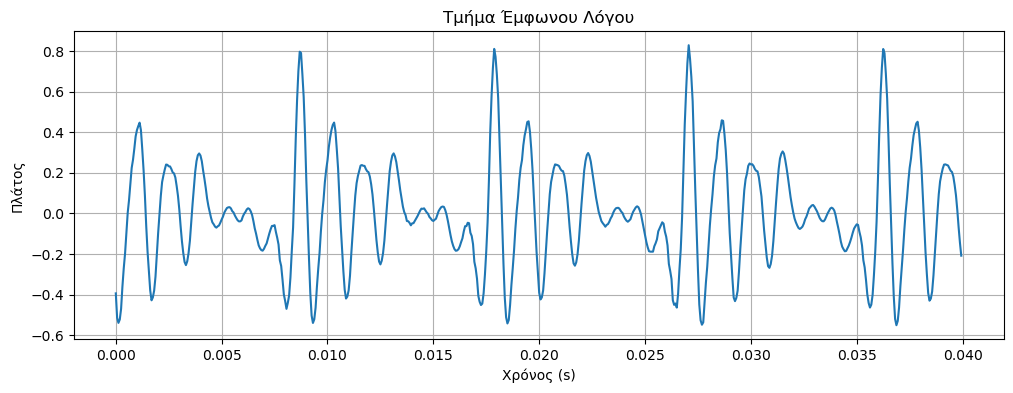

In [4]:
# Γράφημα του τμήματος που κόψαμε
plt.figure(figsize=(12,4))
plt.plot(np.arange(0, len(segment)/fs, 1/fs), segment)
plt.title("Τμήμα Έμφωνου Λόγου")
plt.xlabel("Χρόνος (s)")
plt.ylabel("Πλάτος")
plt.grid()
plt.show()
plt.close()

(εʹ) Μετρήστε "με το μάτι" (χονδρικά) την απόσταση μεταξύ δυο περιόδων του σήματός σας. Ένας ασφαλής τρόπος είναι να μετρήσετε την απόσταση δυο διαδοχικών μεγίστων. Για το σήμα του παραδείγματος, βλέπετε ότι η απόσταση είναι περίπου $T_0 = 0.01$ s. Άρα, χονδρικά, η θεμελιώδης συχνότητα $f_0$ είναι $f_0 = \frac{1}{T_0} = 100$ Hz. Ποια είναι (χονδρικά) η θεμελιώδης συχνότητα στο δικό σας τμήμα φωνής (αν έχετε χρησιμοποιήσει δική σας ηχογράφηση);

(στʹ) Ας δούμε πως μπορούμε να αυτοματοποιήσουμε τη διαδικασία εύρεσης της θεμελιώδους συχνότητας, ώστε να μη βασιζόμαστε στο... "μάτι" μας. 

Υπολογίστε την αυτοσυσχέτιση $\phi_{x}(\tau)$ με χρήση της συνάρτησης $\texttt{correlate}$ και $\texttt{correlation\_lags}$, όπως στην προηγούμενη άσκηση.

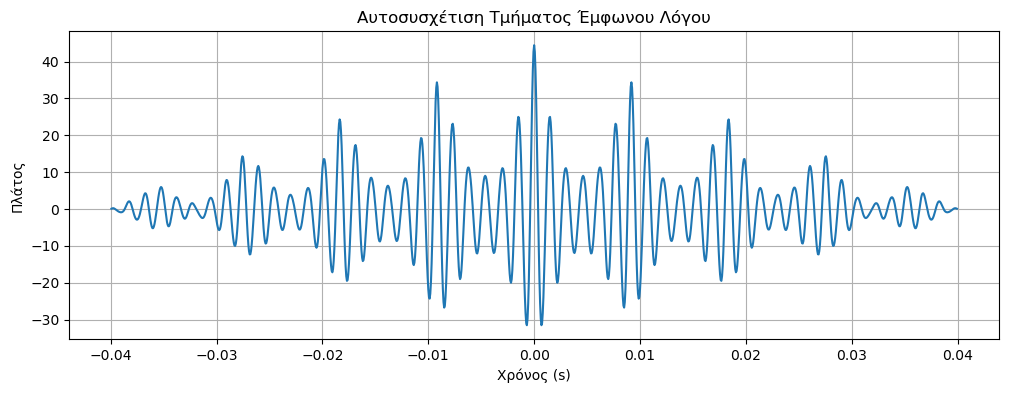

In [5]:
# Αυτοσυσχέτιση
phi = correlate(segment, segment, mode="full")
# Άξονας χρόνου τ
lags = correlation_lags(len(segment), len(segment), mode="full")
# Γράφημα
plt.figure(figsize=(12,4))
plt.plot(lags/fs, phi)
plt.title("Αυτοσυσχέτιση Τμήματος Έμφωνου Λόγου")
plt.xlabel("Χρόνος (s)")
plt.ylabel("Πλάτος")
plt.grid()
plt.show()
plt.close()

Αν το κάνετε σωστά, θα πρέπει να βρείτε το σχήμα παρακάτω (ξανά, για το σήμα φωνής που σας δίνεται).

![speechAC](./files/speechac.png)

(ζʹ) Παρατηρήστε στο σχήμα, ότι το πρώτο ισχυρότερο μέγιστο (πλην της τιμής $\phi_{x}(0)$, όπου ξέρετε ότι αντιπροσωπεύει την ενέργεια του σήματος) στα δεξιά βρίσκεται στη θετική χρονική στιγμή κοντά στο $τ = 0.009$ s. Αυτή η χρονική στιγμή είναι μια στιγμή μεγάλης ομοιότητας του σήματος με τον εαυτό του, άρα σίγουρα θα συμβαίνει όταν το $x(t + \tau)$ της αυτοσυσχέτισης έχει μετατοπιστεί κατά διάστημα $\tau$ διάρκειας μιας περιόδου $T_0$!! 

Αντίστοιχα, το δεύτερο μέγιστο βρίσκεται τη χρονική στιγμή κοντά στο $\tau = 0.018$ s, όπου αντιστοιχεί σε μετατόπιση του $x(t + \tau)$ κατά διάστημα $τ$ δυο περιόδων, κ.ο.κ.

(ηʹ) Η θεμελιώδης συχνότητα $f_0$ με χρήση της χρονικής στιγμής του πρώτου ισχυρού θετικού τοπικού μεγίστου της αυτοσυσχέτισης είναι $f_0 = 1/0.009 = 111.1$ Hz, που είναι λίγο καλύτερη από τη μέτρηση "με το μάτι" που κάναμε νωρίτερα.

(θʹ) Όμως η μέθοδος της αυτοσυσχέτισης, όπως τη δείξαμε, βασίζεται ξανά σε ‘‘χειροκίνητη’’ εύρεση του πρώτου μεγίστου, "με το μάτι". Επίσης, παρατηρήστε ότι υπάρχουν κι άλλες σημαντικές κορυφές (peaks) πριν το πρώτο ισχυρό τοπικό μέγιστο του θετικού ημιάξονα που επιλέξαμε. Πώς θα επιλέξουμε αυτόματα το σωστό peak και την αντίστοιχη χρονική στιγμή του; 

Συμπληρώστε τον κώδικα `Python` που χρησιμοποιεί τη συνάρτηση $\texttt{argmax}$ της $\texttt{NumPy}$ και βρίσκει το σωστό peak της συνάρτησης αυτοσυσχέτισης, αν γνωρίζετε ότι τα όρια θεμελιωδών συχνοτήτων $f_0$ στους ενήλικες είναι στο διάστημα $[70, 280]$ Hz (και άρα υποψήφιες περίοδοι $T_0=1/f_0$ θα πρέπει να βρίσκονται στο $[1/280, 1/70]$ s). 

Υπόδειγμα κώδικα δίνεται παρακάτω, που πρέπει να συμπληρώσετε:

In [6]:
# Όρια θεμελιωδών συχνοτήτων στους ενήλικες
F0_limits = [70, 280]
# Μετατροπή σε δευτερόλεπτα (μια και φτάσαμε στο τέλος του μαθήματος, ας δούμε και το list comprehension :) )
T0_limits = [1/f for f in reversed(F0_limits)]
print(f"Το διάστημα σε δευτερόλεπτα που θα αναζητήσουμε την περίοδο του έμφωνου λόγου μας στη συνάρτηση αυτοσυσχέτισης θα είναι το {T0_limits[0], T0_limits[1]}") 
# θα πρέπει να πάρετε [0.0035... , 0.01428...]

# Μετατροπή δευτερολέπτων σε δείγματα
# Σε 1 δευτερόλεπτο σήματος έχουμε πάρει fs δείγματα
# Σε 0.01428... ή 0.0035... sec, πόσα δειγματα αντιστοιχούν?
N0_limits = [round(lim*fs) for lim in T0_limits]
print(f"Το διάστημα σε δείγματα που θα αναζητήσουμε την περίοδο του έμφωνου λόγου μας στη συνάρτηση αυτοσυσχέτισης θα είναι το {N0_limits[0], N0_limits[1]}")

# Ας επικεντρωθούμε στο κομμάτι της αυτοσυσχέτισης που βρίσκεται στο θετικό ημιάξονα του χρόνου
middle = len(phi)//2
# Επιλέγουμε το διάστημα σε δείγματα που βρήκαμε μόλις παραπάνω, όπου το μέγιστο peak του θα βρίσκεται τη χρονική στιγμή τ = T0 
lags_new = lags[middle + N0_limits[0]:middle + N0_limits[-1]]
phi_new = phi[middle + N0_limits[0]:middle + N0_limits[-1]]

# Χρησιμοποιήστε την argmax για να βρείτε τη θέση του ισχυρού peak της αυτοσυσχέτισης:
maxind = np.argmax(phi_new)

# Περίοδος σε δευτερόλεπτα
T_0 = lags_new[maxind]/fs

# Θεμελιώδης συχνότητα f0
f0 = 1/T_0
print(f"Η θεμελιώδης συχνότητα μας είναι f0 = {f0} Hz, ενώ η περίοδος μας είναι Τ0 = {T_0} s") # Πρέπει να σας δώσει f0 = 108.8435 Hz

Το διάστημα σε δευτερόλεπτα που θα αναζητήσουμε την περίοδο του έμφωνου λόγου μας στη συνάρτηση αυτοσυσχέτισης θα είναι το (0.0035714285714285713, 0.014285714285714285)
Το διάστημα σε δείγματα που θα αναζητήσουμε την περίοδο του έμφωνου λόγου μας στη συνάρτηση αυτοσυσχέτισης θα είναι το (57, 229)
Η θεμελιώδης συχνότητα μας είναι f0 = 108.843537414966 Hz, ενώ η περίοδος μας είναι Τ0 = 0.0091875 s


(ιʹ) Στατιστικά, αν οι άνδρες έχουν θεμελιώδη συχνότητα ομιλίας μέσα στο διάστημα $[70, 150]$ Hz και οι γυναίκες μέσα στο διάστημα $[180, 280]$ Hz, τότε η συχνότητα που βρήκατε εσείς ανταποκρίνεται στο σωστό διάστημα του φύλου σας; (αν χρησιμοποιήσατε δικό σας σήμα ηχογράφησης - ειδάλλως πρέπει να βρείτε ότι ο ομιλητής που σας δίνουμε εμείς είναι άνδρας)

In [7]:
# Έλεγχος φύλου
male_f0_range = [70, 150]
if male_f0_range[0] <= f0 <= male_f0_range[-1]:
    print("Είστε ενήλικας αρσενικός ομιλητής.")
elif 180 <= f0 <= 280:
    print("Είστε ενήλικας θηλυκός ομιλητής.")
else: 
    print("Έχετε χαμηλό f0 για θηλυκό ομιλητή ή ψηλό f0 για αρσενικό ομιλητή! Φυσικά δεν υπάρχει κανένα πρόβλημα με αυτό.")

Είστε ενήλικας αρσενικός ομιλητής.


---
---